In [95]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlm-practice2/training_set_pixel_size_and_HC.csv
/kaggle/input/mlm-practice2/test_set_pixel_size.csv
/kaggle/input/mlm-practice2/mlm2/test_set/245_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/073_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/137_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/094_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/001_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/034_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/213_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/253_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/221_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/119_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/157_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/120_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/123_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/014_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/329_HC.png
/kaggle/input/mlm-practice2/mlm2/test_set/288_HC.png
/kaggle/input/mlm-practice2/mlm2/test

In [96]:
import os, cv2, math
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim


In [97]:
train = pd.read_csv("/kaggle/input/mlm-practice2/training_set_pixel_size_and_HC.csv")
test = pd.read_csv("/kaggle/input/mlm-practice2/test_set_pixel_size.csv")
train_imgs = "/kaggle/input/mlm-practice2/mlm2/training_set"
test_imgs = "/kaggle/input/mlm-practice2/mlm2/test_set"

In [98]:
train.head()

,filename,pixel size(mm),head circumference (mm)
0,000_HC.png,0.069136,44.30
1,001_HC.png,0.089659,56.81
2,002_HC.png,0.062033,68.75
3,003_HC.png,0.091291,69.00
4,004_HC.png,0.061240,59.81


In [99]:
train.describe().T


,count,mean,std,min,25%,50%,75%,max
pixel size(mm),999.0,0.139846,0.053005,0.049415,0.108801,0.128357,0.157678,0.39328
head circumference (mm),999.0,174.383093,65.282061,44.300000,153.600000,174.060000,189.825000,346.40000


In [100]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
pixel size(mm),335.0,0.141509,0.057843,0.052559,0.109671,0.125103,0.157191,0.371305


In [101]:
print(train.columns)
print(test.columns)


Index(['filename', 'pixel size(mm)', 'head circumference (mm)'], dtype='object')
Index(['filename', 'pixel size(mm)'], dtype='object')


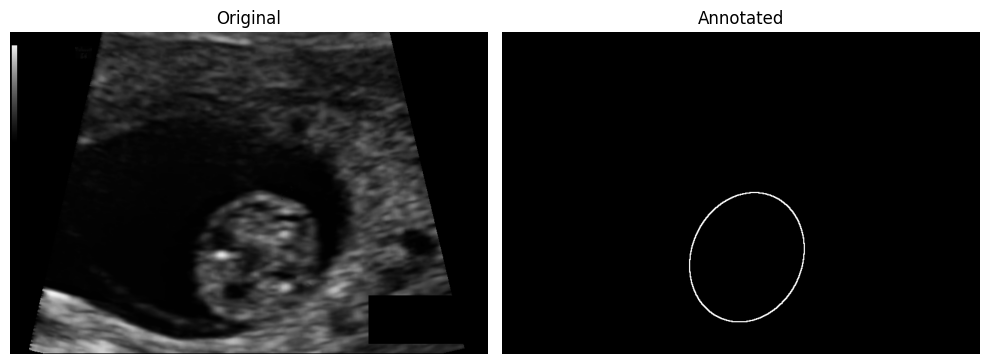

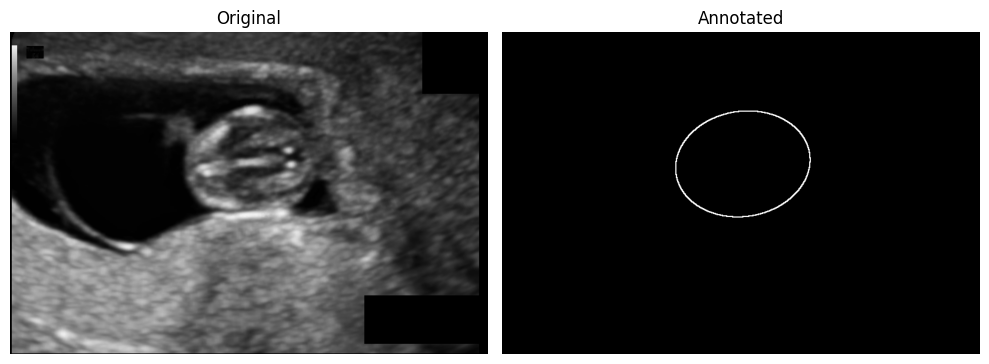

In [102]:
from PIL import Image
import matplotlib.pyplot as plt
image_files = sorted([
    f for f in os.listdir(train_imgs)
    if f.endswith("_HC.png") and "Annotation" not in f
])

for img_name in image_files[0:2]: 
    base = img_name.replace("_HC.png", "")

    original_path = os.path.join(train_imgs, f"{base}_HC.png")
    anno_path     = os.path.join(train_imgs, f"{base}_HC_Annotation.png")

    original = cv2.imread(original_path)
    anno = cv2.imread(anno_path)
    
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    anno = cv2.cvtColor(anno, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(anno)
    plt.title("Annotated")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


In [103]:
import cv2
img = cv2.imread("/kaggle/input/mlm-practice2/mlm2/training_set/001_HC.png", 0)
h, w = img.shape

first_five = train["filename"].iloc[:5]

for img_name in first_five:
    img_path = f"{train_imgs}/{img_name}"

    img = cv2.imread(img_path, 0)
    h, w = img.shape

    pixel_size = train.loc[
        train["filename"] == img_name,
        "pixel size(mm)"
    ].values[0]

    print(f"Image: {img_name}")
    print(f"  Image size : {w} × {h} pixels")
    print(f"  Pixel size : {pixel_size:.6f} mm/pixel\n")

Image: 000_HC.png
  Image size : 800 × 540 pixels
  Pixel size : 0.069136 mm/pixel

Image: 001_HC.png
  Image size : 800 × 540 pixels
  Pixel size : 0.089659 mm/pixel

Image: 002_HC.png
  Image size : 800 × 540 pixels
  Pixel size : 0.062033 mm/pixel

Image: 003_HC.png
  Image size : 800 × 540 pixels
  Pixel size : 0.091291 mm/pixel

Image: 004_HC.png
  Image size : 800 × 540 pixels
  Pixel size : 0.061240 mm/pixel



In [104]:
IMG_SIZE = 512

def load_data(df, img_dir, with_mask=True):
    X = []
    Y = []

    for _, row in df.iterrows():
        img_name = row["filename"]
        img_path = os.path.join(img_dir, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        X.append(img)

        if with_mask:
            ann_path = img_path.replace("_HC.png", "_HC_Annotation.png")
            ann = cv2.imread(ann_path, cv2.IMREAD_GRAYSCALE)

            if ann is None:
                continue

            ann = cv2.resize(ann, (IMG_SIZE, IMG_SIZE))

           
            _, ann = cv2.threshold(ann, 127, 255, cv2.THRESH_BINARY)

            mask = np.zeros_like(ann)

            contours, _ = cv2.findContours(
                ann, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            cv2.drawContours(
                mask, contours, -1, 255, thickness=-1
            )  # thickness=-1 = fill

            mask = (mask > 0).astype("float32")
            Y.append(mask)

    X = np.array(X, dtype="float32")[..., None]

    if with_mask:
        Y = np.array(Y, dtype="float32")[..., None]
        return X, Y
    else:
        return X

In [105]:
X_train, y_train = load_data(train, train_imgs, with_mask = True)

In [106]:
def sample(img_path, ann_path, img_size = 512):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))

    ann = cv2.imread(ann_path, cv2.IMREAD_GRAYSCALE)
    ann = cv2.resize(ann, (img_size, img_size))
    _, ann_bin = cv2.threshold(ann, 127, 255, cv2.THRESH_BINARY)

    mask = np.zeros_like(ann_bin)

    contours, _ = cv2.findContours(
        ann_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(mask, contours, -1, 255, thickness=-1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Annotation")
    plt.imshow(ann_bin, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Filled Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


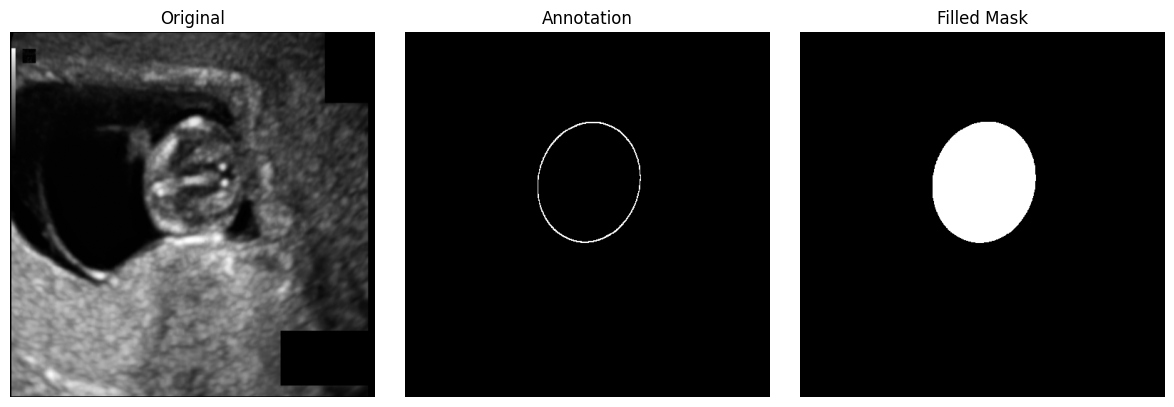

In [107]:
img = "/kaggle/input/mlm-practice2/mlm2/training_set/001_HC.png"
ann = "/kaggle/input/mlm-practice2/mlm2/training_set/001_HC_Annotation.png"

sample(img, ann)

In [108]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate,BatchNormalization
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    return x


def build_unet(input_shape=(512, 512, 1)):
    inputs = Input(input_shape)

    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D(2)(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D(2)(c2)

    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D(2)(c3)

    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D(2)(c4)

    c5 = conv_block(p4, 1024)

    u6 = UpSampling2D(2)(c5)
    u6 = Concatenate()([u6, c4])
    c6 = conv_block(u6, 512)

    u7 = UpSampling2D(2)(c6)
    u7 = Concatenate()([u7, c3])
    c7 = conv_block(u7, 256)

    u8 = UpSampling2D(2)(c7)
    u8 = Concatenate()([u8, c2])
    c8 = conv_block(u8, 128)

    u9 = UpSampling2D(2)(c8)
    u9 = Concatenate()([u9, c1])
    c9 = conv_block(u9, 64)

    outputs = Conv2D(1, 1, activation="sigmoid")(c9)

    return Model(inputs, outputs)


In [109]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return 1 - (2. * intersection + smooth) / (union + smooth)

In [110]:
model = build_unet((IMG_SIZE, IMG_SIZE, 1))

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=["accuracy"]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 512, 512,  │        640 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_76[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 512, 512,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_77[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_16… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_78[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 256, 256,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_79[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 128, 128,  │    295,168 │ max_pooling2d_17… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_80[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 128, 128,  │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_81[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_18

 Total params: 31,401,345 (119.79 MB)

 Trainable params: 31,389,569 (119.74 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [111]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=1,
    shuffle=True
)

Epoch 1/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 128s 137ms/step - accuracy: 0.8109 - loss: 0.3627 - val_accuracy: 0.8423 - val_loss: 0.4356
Epoch 2/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 107s 133ms/step - accuracy: 0.8998 - loss: 0.2391 - val_accuracy: 0.8506 - val_loss: 0.4065
Epoch 3/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 107s 134ms/step - accuracy: 0.9129 - loss: 0.2307 - val_accuracy: 0.8218 - val_loss: 0.5118
Epoch 4/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 107s 134ms/step - accuracy: 0.9246 - loss: 0.1993 - val_accuracy: 0.8695 - val_loss: 0.3718
Epoch 5/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 107s 133ms/step - accuracy: 0.9248 - loss: 0.2001 - val_accuracy: 0.8509 - val_loss: 0.4252
Epoch 6/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 107s 133ms/step - accuracy: 0.9179 - loss: 0.2129 - val_accuracy: 0.8669 - val_loss: 0.3692
Epoch 7/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 107s 134ms/step - accuracy: 0.9324 - loss: 0.1777 - val_accuracy: 0.8891 - val_loss: 0.2984
Epoch 8/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 107s 134ms/step - accuracy: 0.9258 -

In [112]:
model.save("unet_model.keras")


In [113]:
pred_train = model.predict(X_train, batch_size=1)

999/999 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step


In [114]:
pred_train_mask = (pred_train > 0.5).astype("uint8")


In [115]:
def calculate_hc_mm(mask, pixel_size_mm):
    
    if mask.ndim == 3:
        mask = mask.squeeze()

    mask = (mask > 0).astype("uint8") * 255

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    cnt = max(contours, key=cv2.contourArea)

    if len(cnt) < 5:
        return None

    ellipse = cv2.fitEllipse(cnt)

    (_, _), (MA, ma), _ = ellipse

    a = MA / 2
    b = ma / 2

    h = ((a - b) ** 2) / ((a + b) ** 2)
    hc_pixel = np.pi * (a + b) * (1 + (3 * h) / (10 + np.sqrt(4 - 3 * h)))

    hc_mm = hc_pixel * pixel_size_mm

    return hc_mm

In [116]:
hc_pred = []

for i, row in train.iterrows():

    mask = pred_train_mask[i]
    pixel_size = row["pixel size(mm)"]

    hc_mm = calculate_hc_mm(mask, pixel_size)

    hc_pred.append(hc_mm)

train["HC_pred_mm"] = hc_pred

In [117]:
print(train.head(10))

     filename  pixel size(mm)  head circumference (mm)  HC_pred_mm
0  000_HC.png        0.069136                    44.30   36.409687
1  001_HC.png        0.089659                    56.81   56.547027
2  002_HC.png        0.062033                    68.75   66.036213
3  003_HC.png        0.091291                    69.00   53.545328
4  004_HC.png        0.061240                    59.81   46.420230
5  005_HC.png        0.115814                    69.80   53.075129
6  006_HC.png        0.065606                    67.84   51.653688
7  007_HC.png        0.109362                    62.80   50.181818
8  008_HC.png        0.077655                    62.10   37.832211
9  009_HC.png        0.121525                    62.31   50.718791


In [118]:
eval_df = train.dropna(subset=["head circumference (mm)", "HC_pred_mm"])
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    eval_df["head circumference (mm)"],
    eval_df["HC_pred_mm"]
)

print("MAE:", mae)

MAE: 50.49541170261474


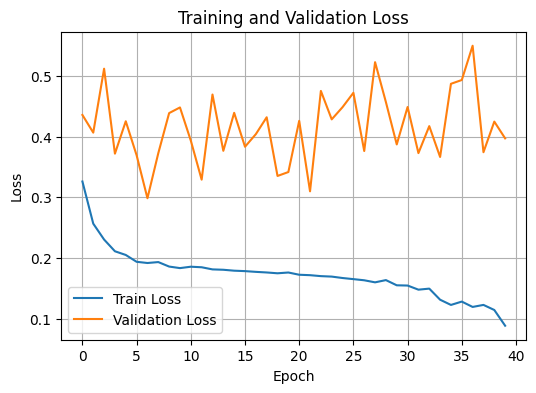

In [119]:
plt.figure(figsize=(10,6))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [120]:
def visualize_prediction(img, mask_pred, hc_gt, hc_pred):

    img = img.squeeze()
    mask = mask_pred.squeeze().astype("uint8") * 255

    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    vis = cv2.cvtColor((img * 255).astype("uint8"), cv2.COLOR_GRAY2BGR)

    if len(contours) > 0 and len(contours[0]) >= 5:
        cnt = max(contours, key=cv2.contourArea)
        ellipse = cv2.fitEllipse(cnt)
        cv2.ellipse(vis, ellipse, (255, 0, 0), 2)

    diff = hc_pred - hc_gt

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Predicted Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title(
        f"Ellipse & HC\nGT: {hc_gt:.1f} mm | Pred: {hc_pred:.1f} mm\nΔ = {diff:.2f} mm"
    )
    plt.imshow(vis)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

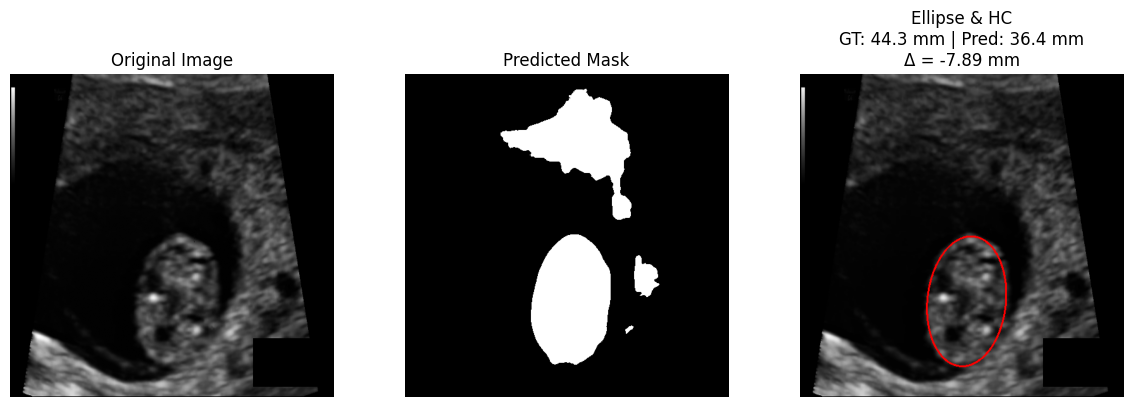

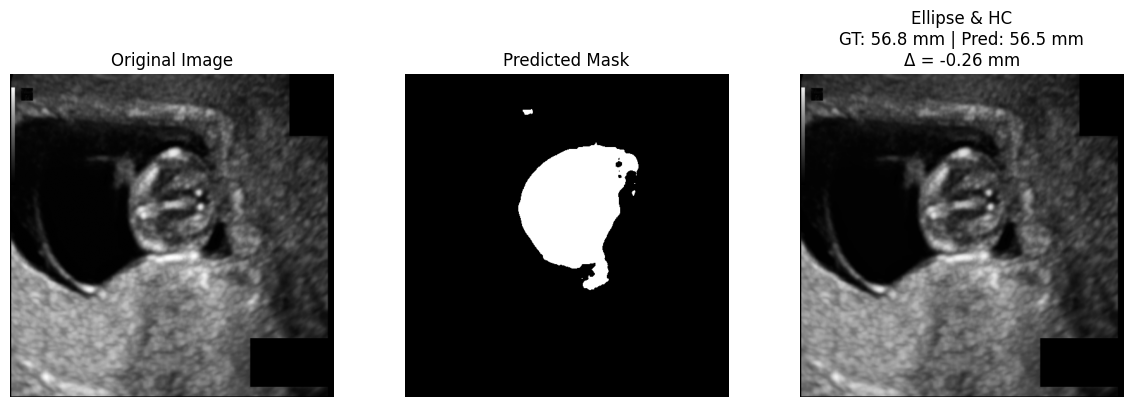

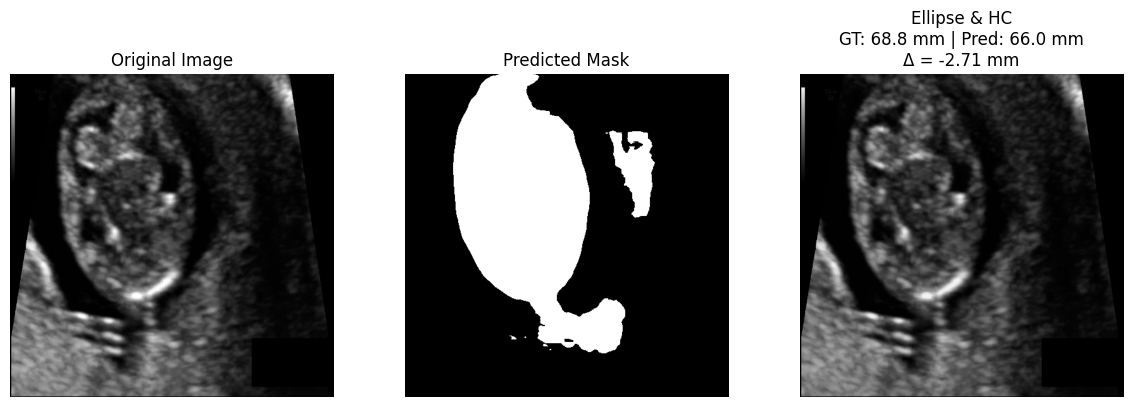

In [122]:
for i in range(3):

    visualize_prediction(
        X_train[i],
        pred_train_mask[i],
        train.loc[i, "head circumference (mm)"],
        train.loc[i, "HC_pred_mm"]
    )
